<a href="https://colab.research.google.com/github/Lu1sV1rus/Estocasticos/blob/main/Tutorial_de_Sympy_y_Networkx.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<font size="6" color="lime"><b>SymPy</b></font>

<p>SymPy es una librería de Python especializada en matemáticas simbólicas. Esto significa que en lugar de darnos resultados con decimales aproximados, trabaja con matrices, fracciones y variables exactas</p>

---

<font color="green">!pip install sympy</font>: <br>
Descarga e instala la herramienta en nuestro entorno. El signo de exclamación (<b>!</b>) le indica a la libreta que ejecute una orden directa al sistema operativo, no como código Python normal.
<br>
<font color="green">import sympy as sp</font>: <br>
Llama a la librería para que esté activa y lista para usarse. Le ponemos el apodo <font color="green">sp</font> por pura comodidad, para no tener que escribir la palabra completa cada vez que usemos una de sus funciones.


In [178]:
#!pip install sympy    # Descargamos e instalamos la libreria
import sympy as sp     # Importamos la libreria

<font color="green">sp.Eq(lado_izquierdo, lado_derecho)</font>: <br>
Construye una ecuación visual (Equality). Toma lo que pongamos a la izquierda, le pone un signo <b>=</b> en el centro, y coloca el resultado a la derecha.

In [210]:
def imp(M,sol):
  f, c = sol.shape
  nom= sp.MatrixSymbol(M, f, c)
  ecuacion = sp.Eq(nom, sol)
  display(ecuacion)

<font size="5" color="tomato">Matrices</b></font>

<p>Para construir una matriz, introducimos listas dentro de listas. Una vez creada, podemos extraer información específica.</p>

---

<font color="red">A= sp.MatrixSymbol('A', 2, 2)</font>: <br>
Crea una "matriz fantasma" o simbólica de 2x2. Sirve únicamente para representar visualmente la letra 'A' en nuestras ecuaciones, avisándole a la librería sus dimensiones reales para que sepa que estamos haciendo álgebra lineal.

In [211]:
A = sp.MatrixSymbol('A', 2, 2)      # Matriz representativa

<font color="red">sp.Matrix( [[...], [...]] )</font>: <br>
Construye una matriz real con números. Cada bloque entre corchetes internos representa un renglón horizontal.

<font color="red">display()</font>: <br>
Muestra el resultado en la libreta con un formato matemático elegante. Es muy útil cuando queremos imprimir varias matrices en una misma celda con un estilo similar al LateX.


In [216]:
# Definimos una matriz A
Am = sp.Matrix([[1, 4],       # Fila 1
               [7, 9]])       # Fila 2

imp(A, Am)                   # Imprimo la matriz A

Eq(A, Matrix([
[1, 4],
[7, 9]]))


<font color="red">A[0, 1]</font>: <br>
Obtiene una entrada específica indicando <font color="red">[renglón, columna]</font>.

In [234]:
# Obtener una entrada específica:
a = Am[0,0]           # Guardo el valor de a0 en a
print('A[0,0] =',a)   # Imprimo el valor de a0

A[0,0] = 1


<font color="red">A.row(0)</font> y <font color="red">A.col(1)</font>: <br>
Extraen un renglón completo o una columna completa, respectivamente.

In [228]:
# Obtener un renglón (fila)
ren = Am.row(0)          # Guardo la fila
imp('Renglon_0', ren)    # Imprimo

# Obtener una columna
col = Am.col(1)          # Guardo la columna
imp('Columna_1', col)    # Imprimo

Eq(Renglon_0, Matrix([[1, 4]]))

Eq(Columna_1, Matrix([
[4],
[9]]))

<font size="5" color="skyblue">Multiplicación y Potencias</font>

<p>Para operar con matrices en SymPy podemos multiplicar matrices entre sí o elevarlas a cualquier potencia usando los símbolos matemáticos estándar de Python.</p>

---

<font color="blue">A * B</font>: <br>
Realiza la multiplicación algebraica de matrices (filas por columnas). A diferencia de otras librerías numéricas, SymPy entiende automáticamente que se trata de un producto matricial exacto.
<br><br>
<font color="blue">A**2</font>: <br>
Eleva la matriz a una potencia dada usando el doble asterisco. Es el equivalente algebraico exacto de multiplicar la matriz por sí misma (A * A).

In [246]:
B = sp.MatrixSymbol('B', 2, 2)  # Matriz representativa B

Bm = sp.Matrix([[5, 6],         # Creo una Matriz B
               [7, 8]])

# Multiplicación de matrices
mul = Am * Bm     # Multiplico (A * B)
imp('A*B',mul)    # Imprimo

print('\n')

# Elevar una matriz a una potencia
A2 = Am**2       # Elevo (A)²
imp('A²',mul)    # Imprimo

Eq(A*B, Matrix([
[33,  38],
[98, 114]]))

Eq(A², Matrix([
[33,  38],
[98, 114]]))

<font size="5" color="pink">Matriz-Vector</font>

<p>Un vector columna es, en esencia, una matriz de una sola columna. Al multiplicarlo por una matriz, estamos aplicando una transformación lineal al espacio.</p>

---

<font color="violet">sp.Matrix([-1, 1])</font>: <br>
Crea un vector columna (una lista simple).
<br>

<font color="violet">Am * vm</font>: <br>
Realiza el producto. El resultado es un nuevo vector que representa la posición transformada tras aplicar la matriz <font color="violet">A<</font>> sobre <font color="violet">v<</font>>.


In [242]:
# Vector-Columna
vm = sp.Matrix([-1, 1])   # Creo un vector
imp('v',vm)               # Imprimo

# Multiplicar la matriz A por el vector v
Av = Am * vm              # Multiplico (A * v)
imp('A*v',Av)             # Imprimo

Eq(v, Matrix([
[-1],
[ 1]]))

Eq(A*v, Matrix([
[3],
[2]]))

<font size="5" color="brown">Diagonalización: Valores y Vectores Propios</font>

<p>La diagonalización descompone una matriz <font color="orange">A</font> en el producto <font color="orange">PDP⁻¹</font>. Es la forma más limpia de obtener toda la información estructural de una matriz en un solo paso.</p>

---

<font color="orange">Am.diagonalize()</font>: <br>
Calcula simultáneamente los vectores propios y los valores propios. Devuelve dos matrices: <font color="orange">P</font> (cuyas columnas son los vectores propios) y <font color="orange">D</font> (una matriz diagonal con los valores propios).
<br><br>
<font color="orange">Matriz P</font>: <br>
Contiene los vectores que definen las direcciones principales de la transformación.
<br><br>
<font color="orange">Matriz D</font>: <br>
Contiene los escalares (valores propios) asociados a cada vector de la matriz <font color="orange">P</font>.

In [243]:
P, D = Am.diagonalize()
print("Matriz P (Vectores propios en las columnas):")
display(P)

print("\nMatriz D (Valores propios en la diagonal):")
display(D)

Matriz P (Vectores propios en las columnas):


Matrix([
[-2*sqrt(11)/7 - 4/7, -4/7 + 2*sqrt(11)/7],
[                  1,                   1]])


Matriz D (Valores propios en la diagonal):


Matrix([
[5 - 2*sqrt(11),              0],
[             0, 5 + 2*sqrt(11)]])

<font size="4" color="brown">Eigenvectores</font>

---

<font color="grey">Am.eigenvects()</font>: <br>
Devuelve una lista de tuplas. Cada tupla contiene: el valor propio, cuántas veces se repite (multiplicidad) y una lista con los vectores propios que pertenecen a ese valor.
<br><br>
<font color="grey">for valor, mult, vectores in resultados:</font> <br>
Es un ciclo que "desempaqueta" la información. Nos permite imprimir etiquetas de texto personalizadas para cada componente, facilitando la lectura de resultados complejos.
<br><br>
<font color="grey">display(v)</font>: <br>
Muestra cada vector propio individual con el formato matemático de la librería.

In [247]:
resultados = Am.eigenvects()

print("Valores y Vectores Propios")
for valor_propio, multiplicidad, vectores in resultados:
    print(f"\nValor Propio: {(valor_propio)}")
    print(f"Multiplicidad algebraica: {multiplicidad}")
    print("Vectores propios asociados:")
    for v in vectores:
        display(v)

Valores y Vectores Propios

Valor Propio: 5 - 2*sqrt(11)
Multiplicidad algebraica: 1
Vectores propios asociados:


Matrix([
[-2*sqrt(11)/7 - 4/7],
[                  1]])


Valor Propio: 5 + 2*sqrt(11)
Multiplicidad algebraica: 1
Vectores propios asociados:


Matrix([
[-4/7 + 2*sqrt(11)/7],
[                  1]])

<font size="6" color="lightgreen">NetworkX</font>

<p>Para visualizar cómo un sistema cambia de un estado a otro, utilizamos grafos dirigidos. En estos diagramas, los nodos representan los estados y las flechas indican la dirección y probabilidad de la transición.</p>

---

<font color="green">import networkx as nx</font>: <br>
Importa la librería principal para la creación, manipulación y estudio de estructuras de redes complejas.
<br><br>
<font color="green">import matplotlib.pyplot as plt</font>: <br>
Importa la herramienta de trazado que NetworkX utiliza "por debajo" para renderizar y mostrar los gráficos en pantalla.

In [140]:
#Importamos la librería
import networkx as nx
import matplotlib.pyplot as plt

<font size="5" color="tomato">Red</font>

<p>Para que el diagrama tenga sentido, debemos conectar los nodos mediante aristas que contengan un valor numérico (peso), el cual representa la probabilidad de transición entre estados.</p>

---

<font color="red">G=nx.DiGraph()</font>: <br>
Crea un objeto de <font color="red">Grafo Dirigido</font>. Es crucial usar este en lugar de un grafo simple para que las flechas tengan una dirección lógica (de origen a destino).
<br>

<font color="red">G.add_weighted_edges_from([...])</font>: <br>
Es la forma más eficiente de cargar múltiples conexiones a la vez. <br>Cada paréntesis <font color="red">('Origen', 'Destino', Peso)</font> define una flecha y el número que lleva encima.
<br>


In [248]:
# Creo un grafo (red) dirigido
G=nx.DiGraph()

# Creo el flujo del grafo
G.add_weighted_edges_from([
    ('A', 'A', 0.2),
    ('A', 'B', 0.7),
    ('A', 'C', 0.1),
    ('B', 'A', 0.3),
    ('B', 'B', 0.1),
    ('B', 'C', 0.6),
    ('C', 'C', 1.0)
])

<font size="5" color="skyblue">Grafico</font>

<p>Para que el diagrama sea legible y profesional, debemos controlar el tamaño del lienzo, la posición de los nodos y las etiquetas de las flechas. Uso <font color="blue">Matplotlib</font> y <font color="blue">NetworkX</font>.</p>

---

<font color="blue">plt.figure(figsize=(8, 6))</font>: <br>
Define el tamaño de la imagen final. Es muy útil para que el diagrama no se vea amontonado en la libreta.
<br>

<font color="blue">nx.spring_layout(G)</font>: <br>
Calcula las posiciones de los nodos usando un algoritmo de simulación física (fuerzas de atracción y repulsión). Esto evita que los círculos se encimen unos con otros.
<br>

<font color="blue">nx.draw_networkx()</font>: <br>
Es la instrucción principal que dibuja los nodos (estados) y las aristas (flechas). Aquí personalizamos el color (<font color="blue">color</font>), tamaño (<font color="blue">size</font>) y grosor (<font color="blue">arrow_size</font>) de las líneas.
<br>

<font color="blue">nx.draw_networkx_edge_labels()</font>: <br>
Dibuja específicamente los pesos o probabilidades sobre cada flecha.
<br>

<font color="blue">plt.show()</font>: <br>
Muestra el grafo.

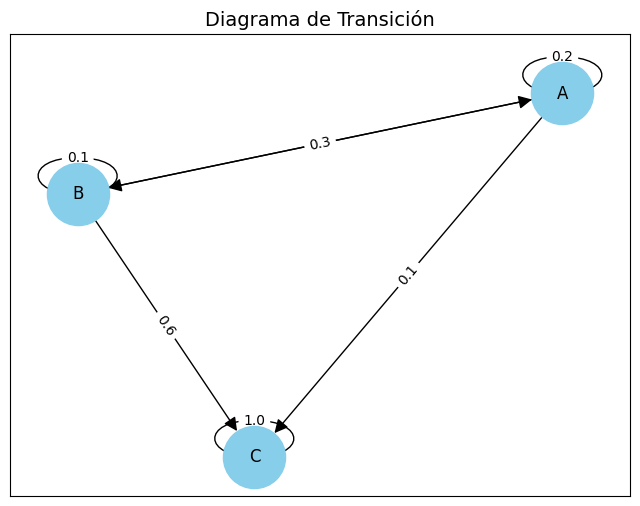

In [259]:
# Grafico
plt.figure(figsize=(8, 6))      # Lienzo

pos = nx.spring_layout(G)       # Posición de los nodos

# Dibujo los nodos
nx.draw_networkx(G, pos,        # Indico el grafo
                 node_color='skyblue',    # Color
                 node_size=2000,          # Tamaño
                 arrowsize=20)            # Grosor

e = nx.get_edge_attributes(G, 'weight')             # Etiquetas
nx.draw_networkx_edge_labels(G, pos, edge_labels=e) # Agrego las etiquetas

# Matplotlib
plt.title("Diagrama de Transición", fontsize=14)    # Titulo
plt.show()                                          # Print